## Introduction

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [74]:
pd.set_option('display.max_columns', None)

In [75]:
df = pd.read_csv('covid_19.csv')
df.columns


Index(['usmer', 'medical_unit', 'sex', 'patient_type', 'date_died', 'intubed',
       'pneumonia', 'age', 'diabetes', 'copd', 'asthma', 'inmsupr',
       'other_disease', 'cardiovascular', 'obesity', 'renal_chronic',
       'tobacco', 'icu', 'pregnancy', 'hypertension', 'covid_res'],
      dtype='object')

In [76]:
df = df.drop(columns=['medical_unit','usmer'],axis=1)
df.head()

,sex,patient_type,date_died,intubed,pneumonia,age,diabetes,copd,asthma,inmsupr,other_disease,cardiovascular,obesity,renal_chronic,tobacco,icu,pregnancy,hypertension,covid_res
0,male,hospitalized,1/1/2027,NaN,No,25,No,No,No,No,No,No,No,No,No,NaN,NaN,No,Negative
1,male,hospitalized,1/1/2027,NaN,No,36,No,No,No,No,No,No,No,No,No,NaN,NaN,No,Negative
2,female,not hospitalized,1/1/2027,No,Yes,47,No,No,No,No,No,No,No,No,No,Not Admitted,No,No,Positive
3,female,hospitalized,1/1/2027,NaN,No,29,No,No,No,No,No,No,No,No,No,NaN,No,No,Negative
4,female,hospitalized,1/1/2027,NaN,No,27,No,No,No,No,No,No,Yes,No,Yes,NaN,No,No,Negative


In [77]:
for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 5:
        print(f"{col}: {unique_vals}")


sex: ['male' 'female']
patient_type: ['hospitalized' 'not hospitalized']
intubed: [nan 'No' 'Yes']
pneumonia: ['No' 'Yes' nan]
diabetes: ['No' 'Yes' nan]
copd: ['No' 'Yes' nan]
asthma: ['No' 'Yes' nan]
inmsupr: ['No' 'Yes' nan]
other_disease: ['No' 'Yes' nan]
cardiovascular: ['No' 'Yes' nan]
obesity: ['No' 'Yes' nan]
renal_chronic: ['No' nan 'Yes']
tobacco: ['No' 'Yes' nan]
icu: [nan 'Not Admitted' 'Admitted']
pregnancy: [nan 'No' 'Yes']
hypertension: ['No' 'Yes' nan]
covid_res: ['Negative' 'Positive']


## Pre-proccessing

### Nan

In [78]:
nan_nums = df.isna().sum()
nan_percentage = (nan_nums/df.shape[0]*100).round(2)
pd.concat(
    [nan_nums, nan_percentage],
    axis=1,
    keys=['nan_numbers', 'nan_percentage']
)

,nan_numbers,nan_percentage
sex,0,0.00
patient_type,0,0.00
date_died,0,0.00
intubed,404170,80.83
pneumonia,3530,0.71
age,0,0.00
diabetes,1443,0.29
copd,1316,0.26
asthma,1308,0.26
inmsupr,1513,0.30


### 2. Data Cleaning, Preparation, and Exploratory Analysis

In [79]:
df.loc[df['sex'] == 'male', 'pregnancy'] = "No"
df['pregnancy'] = df['pregnancy'].fillna('No') 

# df['contact_other_covid'] = df['contact_other_covid'].fillna('Unknown')

#add died column based on date_died

cols = [
    'diabetes','copd','asthma','inmsupr','hypertension',
    'other_disease','cardiovascular','obesity','pneumonia',
    'renal_chronic','tobacco'
]

df[cols] = df[cols].fillna('No')
# df['date_died'] = df['date_died'].fillna(0)


# هر کسی که ICU Admitted بوده، قطعا بستری بوده است
df.loc[df['icu'] == 'Admitted', 'patient_type'] = 'hospitalized'
df.loc[df['intubed'] == 'Yes', 'patient_type'] = 'hospitalized'

# Outpatients: definitely not intubed or in ICU
df.loc[df['patient_type'] == 'not hospitalized', 'intubed'] = 'No'
df.loc[df['patient_type'] == 'not hospitalized', 'icu'] = 'No'

# Inpatients: treat remaining NaN as "No" (most will not be intubed/ICU)
df['icu'] = df['icu'].replace({'Admitted': 'Yes', 'Not Admitted': 'No'}).fillna('No')
df['intubed'] = df['intubed'].fillna('No')

### 2.2 Encoding and Data Type Conversion

In [80]:

df['sex'] = df['sex'].map({
    'male': 2,
    'female': 1
})

binary_map = {'Yes': 1, 'No': 0}
all_binary_cols = [
    'diabetes', 'copd', 'asthma', 'hypertension', 'cardiovascular', 
    'obesity', 'renal_chronic', 'inmsupr', 'other_disease', 'tobacco',
    'pneumonia', 'intubed', 'icu', 'pregnancy'
]

for col in all_binary_cols:
    df[col] = df[col].map(binary_map)

# ۳. انکودینگ سایر متغیرهای چندحالته
df['patient_type'] = df['patient_type'].map({'hospitalized': 1, 'not hospitalized': 0})
df['covid_res'] = df['covid_res'].map({'Positive': 1, 'Negative': 0})
# df['contact_other_covid'] = df['contact_other_covid'].map({'Yes': 1, 'No': 0, 'Unknown': 2})

# ۴. تبدیل به فرمت تاریخ (جاهای خالی NaT می‌مانند که درست است)
# df['date_symptoms'] = pd.to_datetime(df['date_symptoms'], dayfirst=True)
# df['entry_date'] = pd.to_datetime(df['entry_date'], dayfirst=True)
df['died'] = (df['date_died'] != '1/1/2027').astype(int) 


# ۶. تبدیل به int8 برای بهینه‌سازی کامل حافظه
cat_cols = [
    'patient_type', 'intubed', 'pneumonia', 'diabetes',
    'copd', 'asthma', 'inmsupr', 'hypertension',
    'other_disease', 'cardiovascular', 'obesity',
    'renal_chronic', 'tobacco', 
    'covid_res', 'icu', 'died', 'sex', 'pregnancy'
]
df[cat_cols] = df[cat_cols].astype('int8')

In [81]:
df.drop(columns=['date_died'],axis=1,errors='ignore',inplace=True)

In [82]:
cat_cols = [
    'patient_type','intubed','pneumonia','diabetes',
    'copd','asthma','inmsupr','hypertension',
    'other_disease','cardiovascular','obesity',
    'renal_chronic','tobacco',
    'covid_res','icu','died', 'sex', 'pregnancy'
]

df[cat_cols] = df[cat_cols].astype('int8')
df['age'] = df['age'].astype('int16')

### Featuring engineering

In [83]:
# df["days_to_hospital"] = (
#     pd.to_datetime(df["entry_date"]) -
#     pd.to_datetime(df["date_symptoms"])
# ).dt.days

In [84]:
comorbidities = [
    "diabetes",
    "copd",
    "asthma",
    "inmsupr",
    "hypertension",
    "other_disease",
    "cardiovascular",
    "obesity",
    "renal_chronic",
    "tobacco"
]

df["comorbidity_count"] = df[comorbidities].sum(axis=1)

Chronic Disease Score

In [85]:
chronic = [
    "diabetes",
    "copd",
    "asthma",
    "hypertension",
    "cardiovascular",
    "renal_chronic"
]

df["chronic_score"] = df[chronic].sum(axis=1)

high risk disease

In [86]:
df["high_risk"] = (
    (df["age"] >= 60) |
    (df["diabetes"] == 1) |
    (df["hypertension"] == 1) |
    (df["obesity"] == 1)
).astype(int)

In [87]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 35, 50, 65, 80, 120],
    labels=[
        9,
        27,
        43,
        58,
        73,
        85
    ]
)
df.drop('age',axis=1,errors='ignore',inplace=True)

In [88]:
df.head()

,sex,patient_type,intubed,pneumonia,diabetes,copd,asthma,inmsupr,other_disease,cardiovascular,obesity,renal_chronic,tobacco,icu,pregnancy,hypertension,covid_res,died,comorbidity_count,chronic_score,high_risk,age_group
0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,27
1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43
2,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,43
3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,27
4,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,2,0,1,27


## Train-Test Split

In [90]:
import joblib
# df = df[df['covid_res']!=1]
# df['covid_res'] = df['covid_res'].map({0: 0, 2: 1})

In [91]:
y = df['died'].copy().astype(int)
x = df.drop(['covid_res','date_symptoms','died','entry_date','icu'],axis=1,errors='ignore').copy()
print(x.__len__())

500000


In [92]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
    shuffle=True,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
    shuffle=True,
)

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

print("Train:", X_train.shape[0])
print("Validation:", X_val.shape[0])
print("Test:", X_test.shape[0])

c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arrays\base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arrays\base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arrays\base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arrays\base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arrays\base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dt

Train: 350000
Validation: 75000
Test: 75000


c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arrays\base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)


In [94]:
# from imblearn.under_sampling import TomekLinks
# tl = TomekLinks()

# X_small, y_small = tl.fit_resample(
#     X_train_scaled,
#     y_train
# )
# X_small.shape

In [95]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(
    sampling_strategy=1.0,
    random_state=42
)

X_train_bal, y_train_bal = rus.fit_resample(
    X_train_scaled,
    y_train
)

In [96]:
X_train_bal.shape

(53622, 19)

In [98]:
X_train_bal, _, y_train_bal, _ = train_test_split(
    X_train_bal,
    y_train_bal,
    train_size=50000,
    random_state=42,
    stratify=y_train_bal,
    shuffle=True,
)

In [99]:
X_train_bal.shape

(50000, 19)

array([[<Axes: title={'center': 'died'}>]], dtype=object)

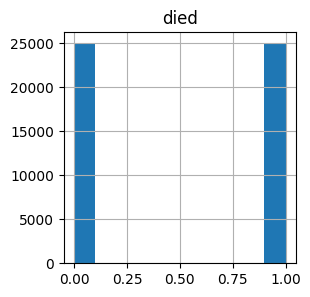

In [100]:
pd.DataFrame(y_train_bal).hist(figsize=(3,3))

In [102]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit

X_combined = np.concatenate([X_train_bal, X_val_scaled])
y_combined = np.concatenate([y_train_bal, y_val])
test_fold = np.concatenate([np.full(len(X_train_bal), -1),np.zeros(len(X_val_scaled))])
ps = PredefinedSplit(test_fold=test_fold)

## Visualization 

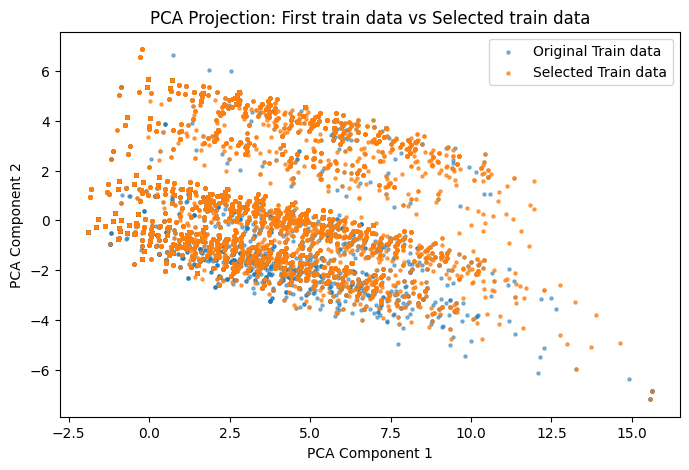

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA



X_plot = np.vstack([
    X_train_scaled,
    X_train_bal
])


pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_plot)


n_train = len(X_train_scaled)

X_train_pca = X_pca[:n_train]
X_candidate_pca = X_pca[n_train:]


train_idx = np.random.choice(
    len(X_train_pca),
    size=50000,
    replace=False
)

cand_idx = np.random.choice(
    len(X_candidate_pca),
    size=25000,
    replace=False
)


plt.figure(figsize=(8,5))
plt.scatter(
    X_train_pca[train_idx,0],
    X_train_pca[train_idx,1],
    s=5,
    alpha=0.5,
    label="Original Train data"
)

plt.scatter(
    X_candidate_pca[cand_idx,0],
    X_candidate_pca[cand_idx,1],
    s=5,
    alpha=0.7,
    label="Selected Train data"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection: First train data vs Selected train data")

plt.legend()
plt.show()

In [104]:
y.value_counts()

died
0    461698
1     38302
Name: count, dtype: int64

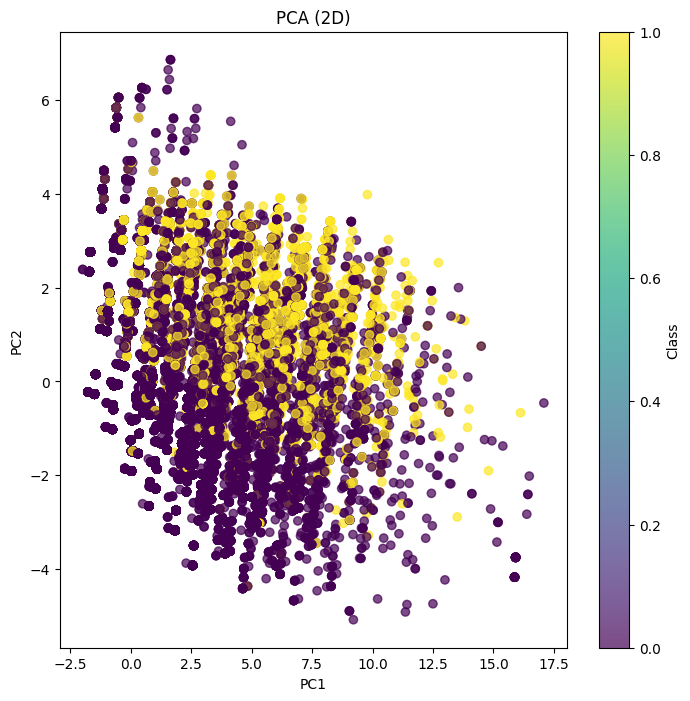

In [105]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
# import umap.umap_ as umap

scaler = StandardScaler()
scaled = scaler.fit_transform(X_train_scaled)

#----------------------------------------------------
# PCA 2D
#----------------------------------------------------
pca2 = PCA(n_components=2)
pca_2d = pca2.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(pca_2d, columns=['PC1', 'PC2'])

#----------------------------------------------------
# t-SNE 2D
#----------------------------------------------------
# tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,)
# tsne_2d = tsne.fit_transform(y)

# tsne_df = pd.DataFrame(tsne_2d, columns=['TSNE1', 'TSNE2'])

plt.figure(figsize=(18,8))

# PCA
plt.subplot(1,2,1)
s1 = plt.scatter(
    pca_df['PC1'], pca_df['PC2'],
    c=y_train, cmap='viridis', alpha=0.7
)
plt.title("PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(s1, label="Class")

# t-SNE
# plt.subplot(1,3,2)
# s2 = plt.scatter(
#     tsne_df['TSNE1'], tsne_df['TSNE2'],
#     c=y, cmap='viridis', alpha=0.7
# )
# plt.title("t-SNE (2D)")
# plt.xlabel("TSNE1")
# plt.ylabel("TSNE2")
# plt.colorbar(s2, label="Class")

# # UMAP
# plt.subplot(1,3,3)
# s3 = plt.scatter(
#     umap_df['UMAP1'], umap_df['UMAP2'],
#     c=y, cmap='viridis', alpha=0.7
# )
# plt.title("UMAP (2D)")
# plt.xlabel("UMAP1")
# plt.ylabel("UMAP2")
# plt.colorbar(s3, label="Class")

# plt.tight_layout()
# plt.show()


## Model Training

#### GaussianNB

In [ ]:
from sklearn.naive_bayes import BernoulliNB

nb = BernoulliNB()
nb.fit(
    X_train_bal,y_train_bal
)

joblib.dump(nb, "models/died/Naive_bayes_model.pkl")

['models/Naive_bayes_model.pkl']

#### Lasso Logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=5000,
    random_state=42,
    C=0.1
)

lasso.fit(X_train_bal,y_train_bal)

joblib.dump(lasso, "models/died/lasso_model.pkl")

c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\iCFixer.ir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


['models/lasso_model.pkl']

In [108]:
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lasso.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

print(coef_df)

              Feature  Coefficient
1        patient_type    -0.870193
2             intubed     0.854025
17          high_risk     0.739871
3           pneumonia     0.624793
0                 sex     0.272715
10            obesity    -0.141384
16      chronic_score     0.089017
8       other_disease     0.080946
12            tobacco    -0.080307
13          pregnancy    -0.073224
6              asthma    -0.072862
11      renal_chronic     0.060192
4            diabetes     0.057150
5                copd     0.051139
7             inmsupr     0.037045
18          age_group     0.019056
9      cardiovascular     0.016576
14       hypertension     0.000000
15  comorbidity_count     0.000000


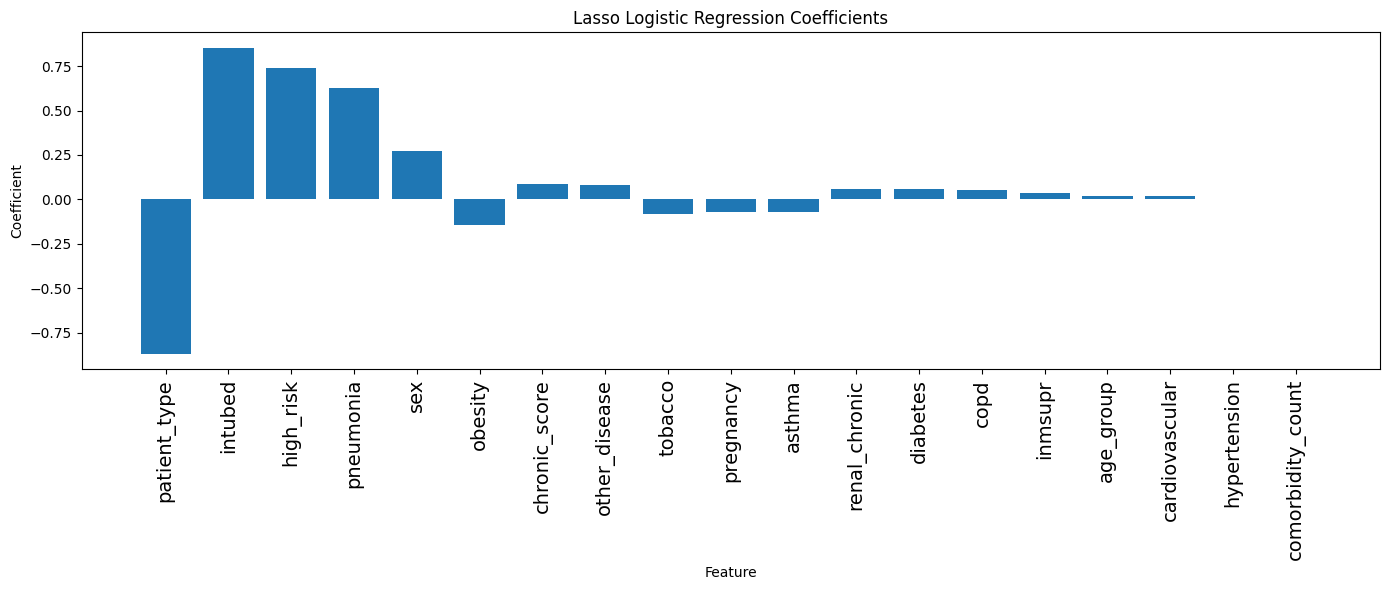

In [109]:
import matplotlib.pyplot as plt

coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(
    coef_df['Feature'],
    coef_df['Coefficient']
)

plt.xticks(rotation=90,fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('Lasso Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

#### XGboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import make_scorer, fbeta_score

f2_scorer = make_scorer(
    fbeta_score,
    beta=1.5,
    pos_label=1
)
# sample_weights = compute_sample_weight(
#     class_weight="balanced",
#     y=y_combined
# )
param_dist = {
    "n_estimators": [200,300,500,1000],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.05,0.1,0.001],
    "min_child_weight": [2, 5, 10,15]
}
xgb = XGBClassifier(
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    eval_metric="logloss"
)
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    cv=ps,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=10,
    random_state=42
)

# random_search.fit(X_combined,y_combined,sample_weight=sample_weights)
random_search.fit(X_combined,y_combined)

best_xgb = random_search.best_estimator_
print(random_search.best_params_)
print(random_search.best_score_)

joblib.dump(best_xgb, "models/died/xgb_model.pkl")

Fitting 1 folds for each of 50 candidates, totalling 50 fits
{'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.05}
0.6471166264248414


['models/xgb_model.pkl']

#### Random Forest

In [112]:
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=ps,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=10,
    random_state=42
)

random_search.fit(X_combined, y_combined)

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 1 folds for each of 30 candidates, totalling 30 fits
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 7}
0.6450437181901229


In [ ]:
joblib.dump(random_search.best_estimator_, "models/died/random_forest_model.pkl")

['models/random_forest_model.pkl']

#### KNN

In [115]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score,accuracy_score
import numpy as np
import plotly.graph_objects as go

ks = range(1, 60, 2)

f1_scores = []

for k in ks:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        n_jobs=-1
    )

    knn.fit(
        X_train_bal,
        y_train_bal
    )

    pred = knn.predict(X_val_scaled)

    score = f1_score(y_val,pred)

    f1_scores.append(score)

best_k = ks[np.argmax(f1_scores)]

print("Best k:", best_k)
print("Best Validation F1:", max(f1_scores))


fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=list(ks),
        y=f1_scores,
        mode="lines+markers",
        name="Validation F1"
    )
)

fig.update_layout(
    title="KNN Validation F1 vs k",
    xaxis_title="k",
    yaxis_title="F1 Macro"
)

fig.show()

Best k: 5
Best Validation F1: 0.5289621882542237


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
best_k=56
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

joblib.dump(knn, "models/died/knn_model.pkl")

['models/knn_model.pkl']

## Visualization 

In [166]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap

pca = PCA(
    n_components=2,
    random_state=42
)
X_pca = pca.fit_transform(X_train_bal)

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42,
    verbose=0
).fit_transform(X_pca)

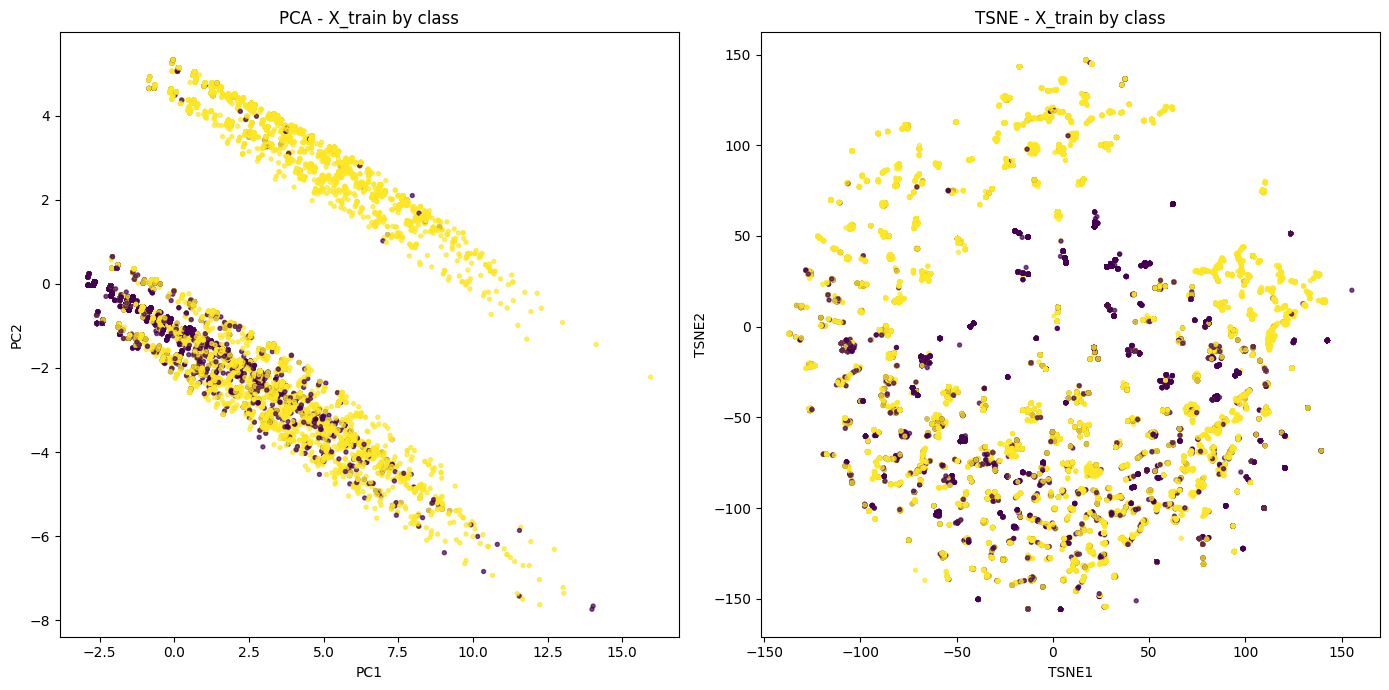

In [167]:

fig, axes = plt.subplots(1,2,figsize=(14,7))
axes[0].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train_bal,
    s=8,
    alpha=0.7,
)
axes[0].set_title("PCA - X_train by class")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y_train_bal,
    s=8,
    alpha=0.7,
)
axes[1].set_title("TSNE - X_train by class")
axes[1].set_xlabel("TSNE1")
axes[1].set_ylabel("TSNE2")

plt.tight_layout()
plt.show()

## Evaluation & Results

In [138]:
lasso_model = joblib.load("models/died/lasso_model.pkl")
knn_model = joblib.load("models/died/knn_model.pkl")
random_forest_model = joblib.load("models/died/random_forest_model.pkl")
naive_bayes_model = joblib.load("models/died/naive_bayes_model.pkl")
xgb_model = joblib.load("models/died/xgb_model.pkl")

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score,f1_score
import math
from sklearn.metrics import roc_curve, roc_auc_score


def plot_metrics_vs_threshold(model,X,y,start=0.10,end=0.90,step=0.01,title="Metrics vs Decision Threshold"):
    # Get predicted probabilities
    probs = model.predict_proba(X)[:, 1]

    thresholds = np.arange(start, end + step, step)

    precisions = []
    recalls = []
    f1_scores = []
    accuracies = []

    for t in thresholds:
        pred = (probs >= t).astype(int)

        precisions.append(
            precision_score(y, pred, zero_division=0)
        )
        recalls.append(
            recall_score(y, pred, zero_division=0)
        )
        f1_scores.append(
            f1_score(y, pred, zero_division=0)
        )
        accuracies.append(
            accuracy_score(y, pred)
        )

    # Best F1 threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    plt.figure(figsize=(10, 6))

    plt.plot(thresholds, precisions, label="Precision", linewidth=2)
    plt.plot(thresholds, recalls, label="Recall", linewidth=2)
    plt.plot(thresholds, f1_scores, label="F1-score", linewidth=2)
    plt.plot(thresholds, accuracies, label="Accuracy", linewidth=2)

    plt.scatter(
        best_threshold,
        f1_scores[best_idx],
        s=80,
        label="Best F1"
    )

    plt.axvline(
        best_threshold,
        linestyle="--",
        alpha=0.8
    )

    plt.text(
        best_threshold + 0.01,
        f1_scores[best_idx],
        f"Best F1={f1_scores[best_idx]:.3f}\nT={best_threshold:.2f}",
        fontsize=10
    )

    plt.xlabel("Threshold", fontsize=13)
    plt.ylabel("Score", fontsize=13)
    plt.title(title, fontsize=15)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Best Threshold : {best_threshold:.2f}")
    print(f"Accuracy       : {accuracies[best_idx]:.4f}")
    print(f"Precision      : {precisions[best_idx]:.4f}")
    print(f"Recall         : {recalls[best_idx]:.4f}")
    print(f"F1-score       : {f1_scores[best_idx]:.4f}")

    # return {
    #     "best_threshold": best_threshold,
    #     "accuracy": accuracies[best_idx],
    #     "precision": precisions[best_idx],
    #     "recall": recalls[best_idx],
    #     "f1": f1_scores[best_idx]
    # }
def plot_multi_roc(models, model_names, X_test, y_test):

    plt.figure(figsize=(7,6))

    for model, name in zip(models, model_names):

        # get probabilities depending on model type
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:,1]
        else:  # keras model
            y_prob = model.predict(X_test).ravel()

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

    # random classifier
    plt.plot([0,1], [0,1], linestyle="--", color="gray")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves Comparison")
    plt.legend()
    plt.grid(True)

    plt.show()
def plot_confusion_mat(ml_model, x_test1, y_test1,
                       title="Confusion Matrix",
                       threshold=0.5):

    # Get probabilities
    y_prob = ml_model.predict(x_test1).ravel()

    # Apply threshold
    y_pred = (y_prob >= threshold).astype(int)

    # Metrics
    cm = confusion_matrix(y_test1, y_pred)
    accuracy = accuracy_score(y_test1, y_pred)
    precision = precision_score(y_test1, y_pred, zero_division=0)
    recall = recall_score(y_test1, y_pred, zero_division=0)
    f1 = f1_score(y_test1, y_pred, zero_division=0)

    # Plot
    fig, ax = plt.subplots(figsize=(5,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cbar=False,
        ax=ax
    )

    ax.set_title(f"{title},Threshold = {threshold}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    metrics_text = (
        f"Accuracy : {accuracy:.4f}\n"
        f"Precision: {precision:.4f}\n"
        f"Recall   : {recall:.4f}\n"
        f"F1-score : {f1:.4f}"
    )

    ax.text(
        0.5,
        -0.30,
        metrics_text,
        transform=ax.transAxes,
        ha="center",
        fontsize=10
    )

    plt.tight_layout()
    plt.show()
def plot_all_confusions(models, model_names, X_test, y_test, cols=2, threshold=0.5):
    rows = math.ceil(len(models) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 6))

    # Handle the case of a single subplot
    if len(models) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (model, name) in enumerate(zip(models, model_names)):

        # Use probabilities if available
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test)[:, 1]
            predictions = (probs >= threshold).astype(int)

        # Otherwise fall back to normal prediction
        else:
            predictions = model.predict(X_test)

        cm = confusion_matrix(y_test, predictions)

        precision = precision_score(y_test, predictions)
        recall = recall_score(y_test, predictions)
        accuracy = accuracy_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)

        ax = axes[i]

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cbar=False,
            ax=ax
        )

        ax.set_title(f"{name}\nThreshold = {threshold}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

        metrics_text = (
            f"Accuracy : {accuracy:.4f}\n"
            f"Precision: {precision:.4f}\n"
            f"Recall   : {recall:.4f}\n"
            f"F1-score : {f1:.4f}"
        )

        ax.text(
            0.5,
            -0.28,
            metrics_text,
            transform=ax.transAxes,
            ha="center",
            fontsize=11
        )

    # Remove unused axes
    for j in range(len(models), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

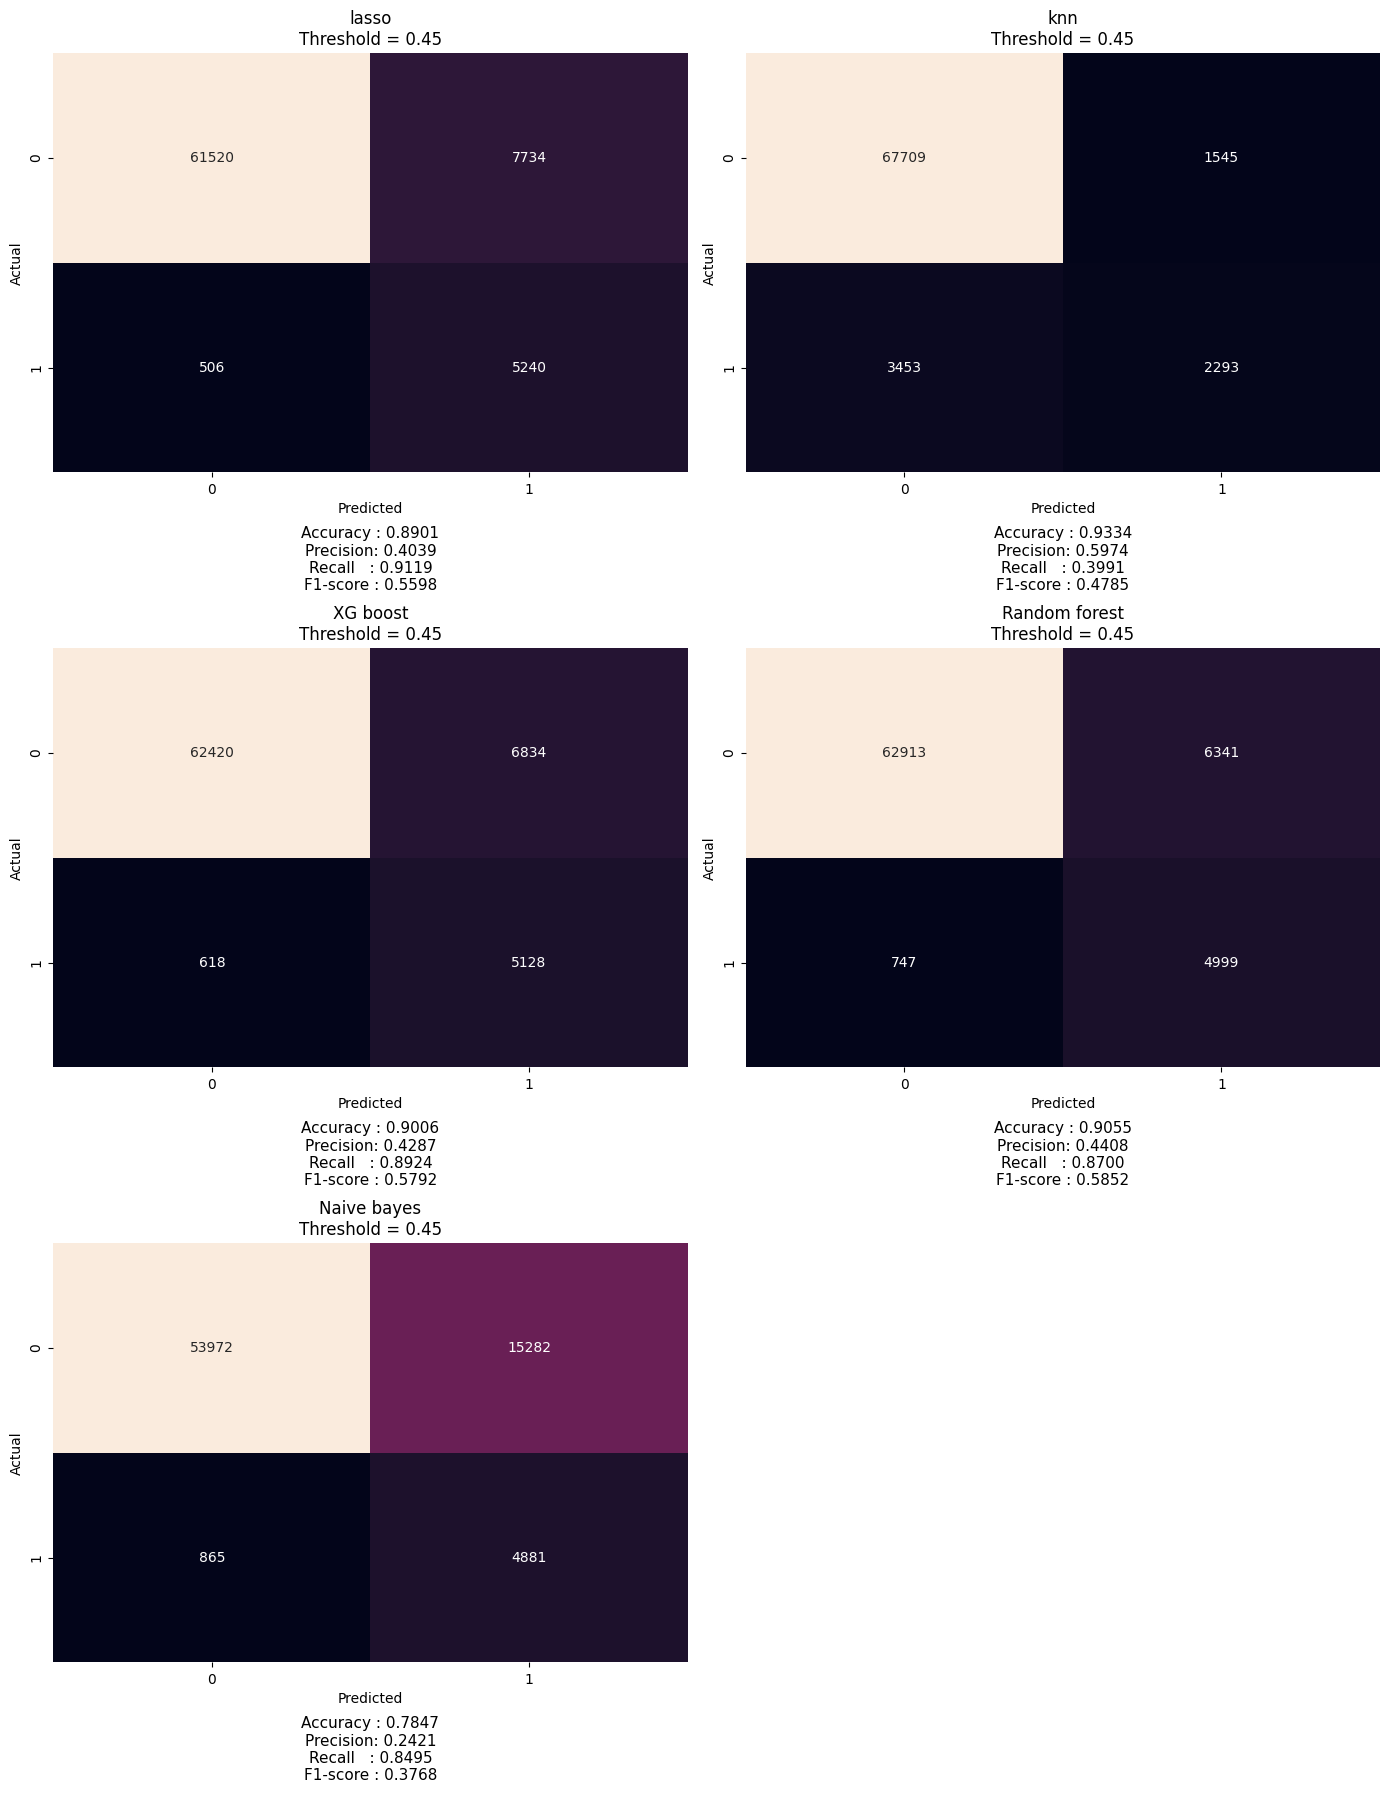

In [140]:
models = [
    lasso_model,
    knn_model,
    xgb_model,
    random_forest_model,
    naive_bayes_model
]

model_names = [
    "lasso",
    "knn",
    "XG boost",
    "Random forest",
    "Naive bayes"
]

plot_all_confusions(models, model_names, X_val_scaled, y_val,threshold=0.45)

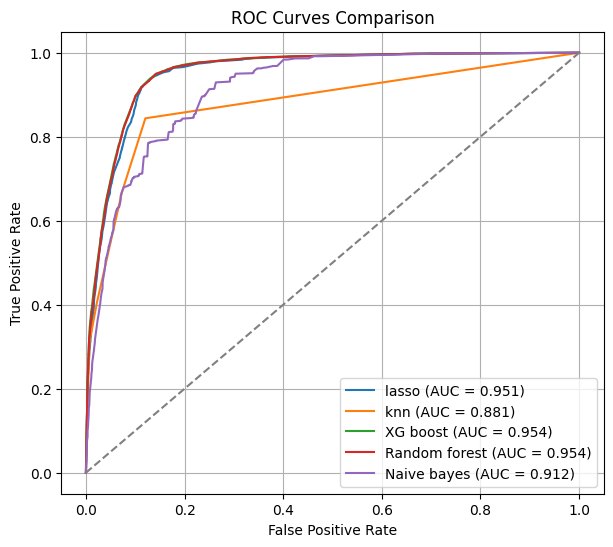

In [141]:
plot_multi_roc(models, model_names, X_test_scaled, y_test)

In [144]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {}

def evaluate_model(model, X, y, name, threshold=0.5):

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)[:, 1]
        y_pred = (probs >= threshold).astype(int)
    else:
        y_pred = model.predict(X)

    results[name] = {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred)
    }
evaluate_model(lasso_model, X_val_scaled, y_val, "Lasso")
evaluate_model(knn_model, X_val_scaled, y_val, "KNN")
evaluate_model(random_forest_model, X_val_scaled, y_val, "Random Forest")
evaluate_model(naive_bayes_model, X_val_scaled, y_val, "Naive Bayes")
evaluate_model(xgb_model, X_val_scaled, y_val, "XGBoost")

summary = (
    pd.DataFrame(results)
      .T
      .round(4)
      .sort_values("f1", ascending=False)
)

display(summary.style.background_gradient(cmap="YlGnBu"))    

,accuracy,precision,recall,f1
Random Forest,0.919100,0.483100,0.791700,0.600000
XGBoost,0.908500,0.449100,0.860400,0.590200
Lasso,0.892100,0.407700,0.901500,0.561500
KNN,0.933400,0.597400,0.399100,0.478500
Naive Bayes,0.786500,0.242600,0.841800,0.376700


### XGB Selected as Final model

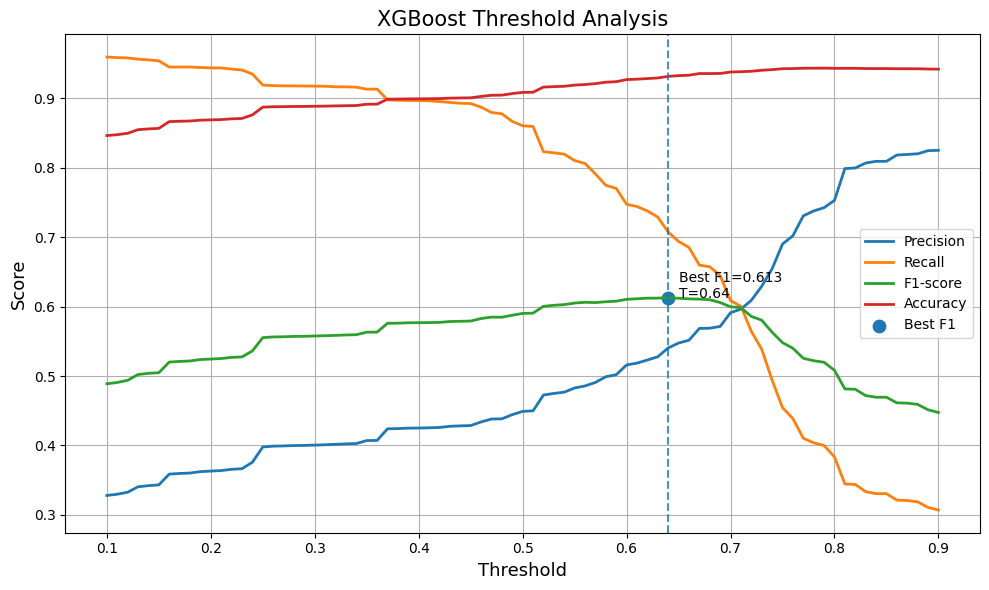

Best Threshold : 0.64
Accuracy       : 0.9315
Precision      : 0.5404
Recall         : 0.7074
F1-score       : 0.6128


In [164]:
plot_metrics_vs_threshold(xgb_model,X_val_scaled,y_val,title="XGBoost Threshold Analysis")

#### Test - result 

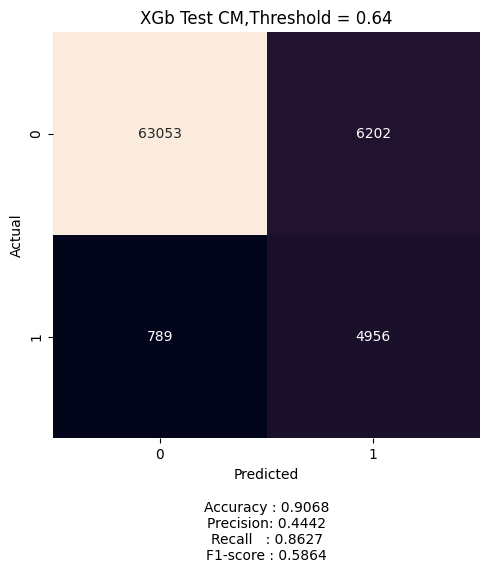

In [156]:
plot_confusion_mat(xgb_model, X_test_scaled, y_test, title="XGb Test CM",threshold=0.64)